In [1]:
import string
import re
import json
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from gensim.models import KeyedVectors
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from pubmed_loader import PubMedQAData

## 0. Configuration
All tunable parameters are defined here for easy adjustment.

In [78]:
# ── Fixed ──────────────────────────────────────────────────────────────────
LABEL_NAMES     = {"yes": 0, "no": 1, "maybe": 2}
LABEL_NAMES_INV = {0: "yes", 1: "no", 2: "maybe"}
RANDOM_SEED     = 11
INPUT_DIM       = 200   # BioWordVec embedding dimension (fixed)
OUTPUT_DIM      = 3     # yes / no / maybe (fixed)

MODEL_PATH = r"E:\0000NLP_Models\BioWordVec_PubMed_MIMICIII_d200.vec.bin"

# ── Model Architecture ─────────────────────────────────────────────────────
HIDDEN_SIZE_1 = 128     # Neurons in first hidden layer
HIDDEN_SIZE_2 = 64      # Neurons in second hidden layer
DROPOUT_RATE  = 0.3     # Dropout probability (higher = stronger regularisation)

# ── Training ───────────────────────────────────────────────────────────────
NUM_EPOCHS    = 15      # Maximum number of training epochs
LEARNING_RATE = 0.001   # Adam learning rate
BATCH_SIZE    = 64      # Samples per gradient update

# ── Class Weighting ────────────────────────────────────────────────────────
USE_CLASS_WEIGHT = True # Whether to apply class weights to handle imbalance
WEIGHT_SCALE     = 3    # Normalisation scale (= number of classes by convention)

# ── Early Stopping ─────────────────────────────────────────────────────────
PATIENCE = 5            # Stop if val loss does not improve for this many epochs

In [79]:
def set_all_seeds(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"All seeds set to {seed}")

set_all_seeds()

All seeds set to 11


## 1. Preprocessing

In [80]:
def clean_text_plus(text):
    text = text.lower()
    keep = {"-"}
    puncts = "".join(c for c in string.punctuation if c not in keep)
    text = text.translate(str.maketrans("", "", puncts))
    tokens = [t for t in text.split() if not re.fullmatch(r"[\d.]+", t)]
    return tokens


def build_input(sample):
    question = sample["QUESTION"]
    context  = " ".join(sample["CONTEXTS"])
    return question + " " + context


def preprocess_biowordvec(dataset, clean_fn=clean_text_plus):
    tokens_list, labels = [], []
    for pmid, sample in dataset.items():
        tokens = clean_fn(build_input(sample))
        tokens_list.append(tokens)
        labels.append(LABEL_NAMES[sample["final_decision"]])
    return tokens_list, labels

In [81]:
data = PubMedQAData("data")

train_tokens, train_labels = preprocess_biowordvec(data.train_set)
dev_tokens,   dev_labels   = preprocess_biowordvec(data.dev_set)

test_tokens, _ = preprocess_biowordvec(data.test_set)
test_pmids     = list(data.test_set.keys())
test_labels    = [LABEL_NAMES[data.test_ground_truth[pmid]] for pmid in test_pmids]

print(f"train: {len(train_tokens)} samples")
print(f"dev:   {len(dev_tokens)}   samples")
print(f"test:  {len(test_tokens)}  samples")
print("Train:", np.bincount(train_labels))
print("Dev:  ", np.bincount(dev_labels))
print("Test: ", np.bincount(test_labels))

train: 450 samples
dev:   50   samples
test:  500  samples
Train: [249 152  49]
Dev:   [27 17  6]
Test:  [276 169  55]


## 2. Load BioWordVec & Vectorize

In [82]:
def vectorize(tokens_list, model, dim=INPUT_DIM):
    vectors = []
    for tokens in tokens_list:
        token_vecs = [model[t] for t in tokens if t in model]
        if token_vecs:
            vectors.append(np.mean(token_vecs, axis=0))
        else:
            vectors.append(np.zeros(dim))
    return np.array(vectors)

In [135]:
print("Loading BioWordVec model...")
bwv_model = KeyedVectors.load_word2vec_format(
    MODEL_PATH, binary=True, limit=3000000  
)
print(f"Model loaded. Vocabulary size: {len(bwv_model)}")

Loading BioWordVec model...
Model loaded. Vocabulary size: 3000000


In [136]:
X_train = vectorize(train_tokens, bwv_model)
X_dev   = vectorize(dev_tokens,   bwv_model)
X_test  = vectorize(test_tokens,  bwv_model)

print(f"X_train shape: {X_train.shape}")
print(f"X_dev shape:   {X_dev.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (450, 200)
X_dev shape:   (50, 200)
X_test shape:  (500, 200)


## 3. DataLoader

In [137]:
def to_dataloader(X, labels, batch_size=BATCH_SIZE, shuffle=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(labels, dtype=torch.long)
    return DataLoader(TensorDataset(X_tensor, y_tensor),
                      batch_size=batch_size, shuffle=shuffle)

train_loader = to_dataloader(X_train, train_labels, shuffle=True)
dev_loader   = to_dataloader(X_dev,   dev_labels)
test_loader  = to_dataloader(X_test,  test_labels)

## 4. Model Definition

In [138]:
class MLP(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_size_1=HIDDEN_SIZE_1,
                 hidden_size_2=HIDDEN_SIZE_2, dropout_rate=DROPOUT_RATE):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_size_1),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size_1, hidden_size_2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size_2, OUTPUT_DIM)
        )

    def forward(self, x):
        return self.network(x)

## 5. Class Weights

In [139]:
if USE_CLASS_WEIGHT:
    counts        = np.bincount(train_labels)
    counts_tensor = torch.FloatTensor(counts)
    class_weights = 1.0 / counts_tensor
    class_weights = class_weights / class_weights.sum() * WEIGHT_SCALE
    print(f"counts: {counts}")
    print(f"class_weights: {class_weights}")
else:
    class_weights = None
    print("No class weights applied")

counts: [249 152  49]
class_weights: tensor([0.3886, 0.6366, 1.9748])


## 6. Training with Early Stopping

In [140]:
def train_mlp(model, train_loader, dev_loader,
              num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
              class_weights=None, patience=PATIENCE):

    loss_fn   = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None \
                else nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    all_train_losses, all_dev_losses = [], []
    best_dev_loss = float("inf")
    best_state    = None
    patience_counter = 0

    for epoch in range(num_epochs):
        # ── Train ──
        model.train()
        train_losses, correct, total = [], 0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss   = loss_fn(output, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            correct += (output.argmax(1) == y_batch).sum().item()
            total   += y_batch.size(0)

        train_acc = correct / total * 100
        mean_train_loss = np.mean(train_losses)
        all_train_losses.append(mean_train_loss)

        # ── Validate ──
        model.eval()
        dev_losses, correct, total = [], 0, 0
        with torch.no_grad():
            for X_batch, y_batch in dev_loader:
                output = model(X_batch)
                dev_losses.append(loss_fn(output, y_batch).item())
                correct += (output.argmax(1) == y_batch).sum().item()
                total   += y_batch.size(0)

        dev_acc = correct / total * 100
        mean_dev_loss = np.mean(dev_losses)
        all_dev_losses.append(mean_dev_loss)

        print(f"Epoch {epoch+1}/{num_epochs}  "
              f"Train Loss: {mean_train_loss:.4f}  Train Acc: {train_acc:.2f}%  "
              f"Val Loss: {mean_dev_loss:.4f}  Val Acc: {dev_acc:.2f}%")

        # ── Early Stopping ──
        if mean_dev_loss < best_dev_loss:
            best_dev_loss    = mean_dev_loss
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f"  Best model saved (val_loss={best_dev_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    print(f"Restored best model (val_loss={best_dev_loss:.4f})")
    return model, all_train_losses, all_dev_losses

In [141]:
set_all_seeds()
model = MLP()
trained_model, train_losses, dev_losses = train_mlp(
    model, train_loader, dev_loader, class_weights=class_weights
)

All seeds set to 11
Epoch 1/15  Train Loss: 1.0986  Train Acc: 46.00%  Val Loss: 1.0992  Val Acc: 52.00%
  Best model saved (val_loss=1.0992)
Epoch 2/15  Train Loss: 1.1064  Train Acc: 50.44%  Val Loss: 1.0996  Val Acc: 54.00%
  No improvement. Patience: 1/5
Epoch 3/15  Train Loss: 1.1013  Train Acc: 46.44%  Val Loss: 1.0978  Val Acc: 54.00%
  Best model saved (val_loss=1.0978)
Epoch 4/15  Train Loss: 1.1000  Train Acc: 40.44%  Val Loss: 1.0986  Val Acc: 34.00%
  No improvement. Patience: 1/5
Epoch 5/15  Train Loss: 1.0982  Train Acc: 35.11%  Val Loss: 1.0979  Val Acc: 34.00%
  No improvement. Patience: 2/5
Epoch 6/15  Train Loss: 1.0979  Train Acc: 32.67%  Val Loss: 1.0962  Val Acc: 36.00%
  Best model saved (val_loss=1.0962)
Epoch 7/15  Train Loss: 1.1031  Train Acc: 29.78%  Val Loss: 1.0956  Val Acc: 26.00%
  Best model saved (val_loss=1.0956)
Epoch 8/15  Train Loss: 1.0938  Train Acc: 39.56%  Val Loss: 1.0989  Val Acc: 34.00%
  No improvement. Patience: 1/5
Epoch 9/15  Train Loss: 

## 7. Training Curves

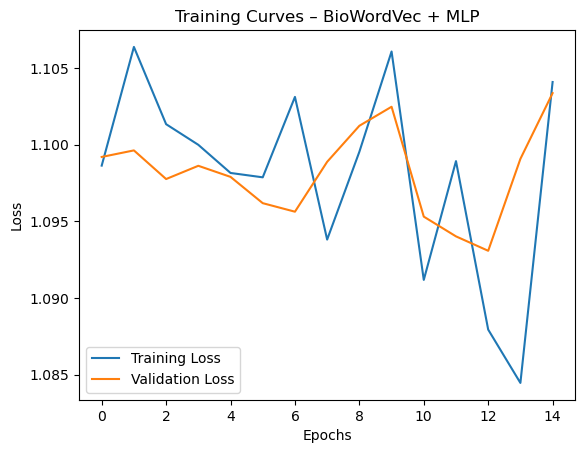

In [142]:
def training_curves(train_losses, dev_losses):
    plt.figure()
    plt.plot(train_losses, label="Training Loss")
    plt.plot(dev_losses,   label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training Curves – BioWordVec + MLP")
    plt.legend()
    plt.show()

training_curves(train_losses, dev_losses)

## 8. Evaluate

In [143]:
def predict(model, loader):
    model.eval()
    gold_labs, pred_labs = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch).argmax(1)
            gold_labs.extend(y_batch.tolist())
            pred_labs.extend(preds.tolist())
    return gold_labs, pred_labs


def evaluate(y_pred, y_true, split_name):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro")
    print(f"\n── {split_name} ──")
    print(f"Accuracy: {acc:.4f}  Macro-F1: {f1:.4f}")
    print(classification_report(y_true, y_pred,
                                target_names=["yes", "no", "maybe"]))


def plot_confusion_matrix(y_true, y_pred):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["yes", "no", "maybe"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix – BioWordVec + MLP")
    plt.show()

In [144]:
y_true, y_pred = predict(trained_model, test_loader)
evaluate(y_pred, y_true, "Test_set")


── Test_set ──
Accuracy: 0.1520  Macro-F1: 0.1391
              precision    recall  f1-score   support

         yes       0.00      0.00      0.00       276
          no       0.33      0.15      0.20       169
       maybe       0.12      0.93      0.21        55

    accuracy                           0.15       500
   macro avg       0.15      0.36      0.14       500
weighted avg       0.13      0.15      0.09       500



g:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
g:\Anaconda\envs\text_analytics\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


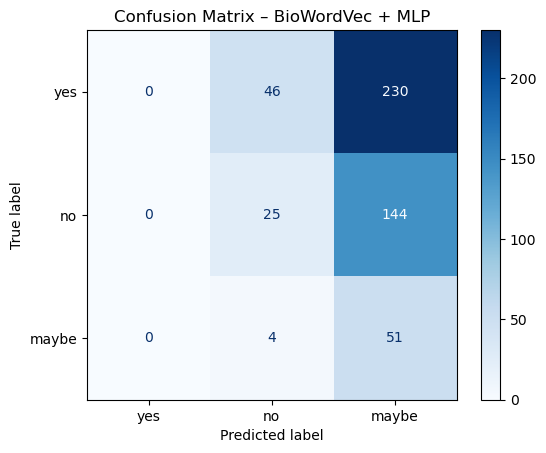

In [145]:
plot_confusion_matrix(y_true, y_pred)

## 9. Error Analysis

In [146]:
print("\nError samples (top 5)")
test_items = list(data.test_set.items())
errors = [
    (pmid, sample, y_true[i], y_pred[i])
    for i, (pmid, sample) in enumerate(test_items)
    if y_true[i] != y_pred[i]
]

for pmid, sample, true, pred in errors[:5]:
    print(f"\nPMID: {pmid}")
    print(f"Question : {sample['QUESTION']}")
    print(f"True     : {LABEL_NAMES_INV[true]}")
    print(f"Predicted: {LABEL_NAMES_INV[pred]}")


Error samples (top 5)

PMID: 12377809
Question : Is anorectal endosonography valuable in dyschesia?
True     : yes
Predicted: maybe

PMID: 26163474
Question : Is there a connection between sublingual varices and hypertension?
True     : yes
Predicted: no

PMID: 19100463
Question : Is the affinity column-mediated immunoassay method suitable as an alternative to the microparticle enzyme immunoassay method as a blood tacrolimus assay?
True     : yes
Predicted: maybe

PMID: 18537964
Question : Does a physician's specialty influence the recording of medication history in patients' case notes?
True     : yes
Predicted: maybe

PMID: 12913878
Question : Locoregional opening of the rodent blood-brain barrier for paclitaxel using Nd:YAG laser-induced thermo therapy: a new concept of adjuvant glioma therapy?
True     : yes
Predicted: maybe
